In [28]:
import subprocess

iterations = 10

for t in range(iterations):
    threads = t+1
    if threads <= 2:
        cpus = "--num-cpus=11"
    else:
        cpus = "--num-cpus=5"

    subprocess.run(["build/ARM/gem5.opt", "configs/example/se_SMT_ARM.py", "../starbench/md5/pthread/md5-arm -i 1 -c 10 -t 10",
                    "--caches", "--l1d_size=32kB", "--l1d_assoc=8", "--l1i_size=32kB", "--l1i_assoc=8", "--l2cache",
                    "--cpu=o3", "--mem-type=DDR4_2400_16x4", "--mem-size=64GB", "--mem-channels=2", cpus, "--smt", "-t", str(threads)])
    # open both files
    filename = "stats/OutputStats_Large_" + str(threads)
    with open("m5out/stats.txt",'r') as firstfile, open(filename,'w') as secondfile: 
        # read content from first file 
        for line in firstfile: 
            # append content to second file 
            secondfile.write(line)

gem5 Simulator System.  https://www.gem5.org
gem5 is copyrighted software; use the --copyright option for details.

gem5 version 22.1.0.0
gem5 compiled Dec 15 2023 01:12:09
gem5 started Dec 15 2023 03:57:47
gem5 executing on red, pid 2687175
command line: build/ARM/gem5.opt configs/example/se_SMT_ARM.py '../starbench/md5/pthread/md5-arm -i 1 -c 10 -t 10' --caches --l1d_size=32kB --l1d_assoc=8 --l1i_size=32kB --l1i_assoc=8 --l2cache --cpu=o3 --mem-type=DDR4_2400_16x4 --mem-size=64GB --mem-channels=2 --num-cpus=11 --smt -t 1

info: Standard input is not a terminal, disabling listeners.
info: 1. command and arguments: ['../starbench/md5/pthread/md5-arm', '-i', '1', '-c', '10', '-t', '10']
<_m5.object_file.ObjectFile object at 0x7f6e4dee6370>   <class '_m5.object_file.ObjectFile'>
system.cpu_cluster.cpus  11  processes  1
STATUS  [<m5.objects.ArmISA.ArmISA object at 0x7f6e4df168e0>]
STATUS  [<m5.objects.ArmISA.ArmISA object at 0x7f6e4df16d60>]
STATUS  [<m5.objects.ArmISA.ArmISA object at 0

warn: The `get_runtime_isa` function is deprecated. Please migrate away from using this function.
warn: No dot file generated. Please install pydot to generate the dot file and pdf.
build/ARM/base/remote_gdb.cc:416: warn: Sockets disabled, not accepting gdb connections
build/ARM/sim/simulate.cc:192: info: Entering event queue @ 0.  Starting simulation...
build/ARM/sim/syscall_emul.cc:74: warn: ignoring syscall set_robust_list(...)
build/ARM/sim/syscall_emul.cc:74: warn: ignoring syscall rt_sigaction(...)
build/ARM/sim/syscall_emul.cc:74: warn: ignoring syscall rt_sigaction(...)
build/ARM/sim/syscall_emul.cc:85: warn: ignoring syscall rt_sigprocmask(...)
      (further warnings will be suppressed)
build/ARM/arch/arm/insts/pseudo.cc:172: warn: 	instruction 'bti' unimplemented
build/ARM/sim/mem_state.cc:456: info: Increasing stack size by one page.
build/ARM/sim/syscall_emul.hh:1021: warn: readlink() called on '/proc/self/exe' may yield unexpected results in various settings.
      Return

KeyboardInterrupt: 

In [25]:
import numpy as np
import re

iterations = 10

#General:
xpoints = np.arange(iterations) + 1
numSecs = np.zeros(iterations)
numCycles = np.zeros(iterations)
utilization = np.zeros(iterations)
totalNumCycles = np.zeros(iterations)
instsEfficiency = np.zeros(iterations)

#Commit:
commit_nonSpecStalls = np.zeros(iterations)
commit_squashedInsts = np.zeros(iterations)

#caches:
dcache_overallMisses = np.zeros(iterations)
icache_overallMisses = np.zeros(iterations)

#decode:
decode_idleCycles = np.zeros(iterations)
decode_blockedCycles = np.zeros(iterations)
decode_squashCycles = np.zeros(iterations)

#fetch:
fetch_icacheStallCycles = np.zeros(iterations)
fetch_miscStallCycles = np.zeros(iterations)
fetch_icacheWaitRetryStallCycles = np.zeros(iterations)

#iew
iew_squashCycles = np.zeros(iterations)
iew_idleCycles = np.zeros(iterations)
iew_blockCycles = np.zeros(iterations)
iew_iqFullEvents = np.zeros(iterations)
iew_lsqFullEvents = np.zeros(iterations)

#rename
rename_squashCycles = np.zeros(iterations)
rename_idleCycles = np.zeros(iterations)
rename_blockCycles = np.zeros(iterations)
rename_serializeStallCycles = np.zeros(iterations)
rename_ROBFullEvents = np.zeros(iterations)

for t in range(iterations):  
    threads = t+1  
    instsCommitted = 0
    instsFetched = 0
    filename = "stats/OutputStats_" + str(threads)
    stats = open(filename)
    for line in stats:
        #General:
        if "simSeconds" in line:
            match = re.search(r'\b\d+\.\d+\b', line)
            if match:
                numSecs[t] += float(match.group())
        if "system.cpu_cluster.cpus0.numCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                numCycles[t] += float(match.group())
        if ".numCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                totalNumCycles[t] += float(match.group())
        if ".committedInsts::total" in line or ".committedInsts " in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                instsCommitted += float(match.group())
        if ".fetch.insts" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                instsFetched += float(match.group())
        #Commit:
        if ".commitNonSpecStalls" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                commit_nonSpecStalls[t] += float(match.group())
        if ".commitSquashedInsts" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                commit_squashedInsts[t] += float(match.group())
        #caches:
        if ".dcache.overallMisses::total" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                dcache_overallMisses[t] += float(match.group())
        if ".icache.overallMisses::total" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                icache_overallMisses[t] += float(match.group())
        #decode:
        if ".decode.idleCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                decode_idleCycles[t] += float(match.group())
        if ".decode.blockedCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                decode_blockedCycles[t] += float(match.group())
        if ".decode.squashCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                decode_squashCycles[t] += float(match.group())
        #fetch:
        if ".fetch.icacheStallCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                fetch_icacheStallCycles[t] += float(match.group())
        if ".fetch.miscStallCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                fetch_miscStallCycles[t] += float(match.group())
        if ".fetch.icacheWaitRetryStallCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                fetch_icacheWaitRetryStallCycles[t] += float(match.group())
        #iew:
        if ".iew.squashCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_squashCycles[t] += float(match.group())
        if ".iew.idleCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_idleCycles[t] += float(match.group())
        if ".iew.blockCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_blockCycles[t] += float(match.group())
        if ".iew.iqFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_iqFullEvents[t] += float(match.group())
        if ".iew.lsqFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_lsqFullEvents[t] += float(match.group())
        #rename:
        if ".rename.squashCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_squashCycles[t] += float(match.group())
        if ".rename.idleCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_idleCycles[t] += float(match.group())
        if ".rename.blockCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_blockCycles[t] += float(match.group())
        if ".rename.serializeStallCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_serializeStallCycles[t] += float(match.group())
        if ".rename.ROBFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_ROBFullEvents[t] += float(match.group())

    utilization[t] = instsCommitted/(totalNumCycles[t]*8)
    instsEfficiency[t] = instsCommitted/instsFetched

In [47]:
import subprocess


subprocess.run(["build/ARM/gem5.opt", "configs/example/se_SMT_ARM.py", "../starbench/md5/pthread/md5-arm -i 1 -c 10 -t 10",
                "--caches", "--l1d_size=32kB", "--l1d_assoc=8", "--l1i_size=32kB", "--l1i_assoc=8", "--l2cache",
                "--cpu=minor", "--mem-type=DDR4_2400_16x4", "--mem-size=64GB", "--mem-channels=2", "--num-cpus=1"])
# open both files
filename = "stats/OutputStats_minor_" + str(threads)
with open("m5out/stats.txt",'r') as firstfile, open(filename,'w') as secondfile: 
    # read content from first file 
    for line in firstfile: 
        # append content to second file 
        secondfile.write(line)

gem5 Simulator System.  https://www.gem5.org
gem5 is copyrighted software; use the --copyright option for details.

gem5 version 22.1.0.0
gem5 compiled Dec 15 2023 01:12:09
gem5 started Dec 15 2023 04:13:48
gem5 executing on red, pid 2687717
command line: build/ARM/gem5.opt configs/example/se_SMT_ARM.py '../starbench/md5/pthread/md5-arm -i 1 -c 10 -t 10' --caches --l1d_size=32kB --l1d_assoc=8 --l1i_size=32kB --l1i_assoc=8 --l2cache --cpu=minor --mem-type=DDR4_2400_16x4 --mem-size=64GB --mem-channels=2 --num-cpus=1

info: Standard input is not a terminal, disabling listeners.
info: 1. command and arguments: ['../starbench/md5/pthread/md5-arm', '-i', '1', '-c', '10', '-t', '10']
<_m5.object_file.ObjectFile object at 0x7f5a1816dd30>   <class '_m5.object_file.ObjectFile'>
system.cpu_cluster.cpus  1  processes  1
STATUS  [<m5.objects.ArmISA.ArmISA object at 0x7f5a1815c4f0>]
Global frequency set at 1000000000000 ticks per second


warn: The `get_runtime_isa` function is deprecated. Please migrate away from using this function.
warn: No dot file generated. Please install pydot to generate the dot file and pdf.
build/ARM/base/statistics.hh:280: warn: One of the stats is a legacy stat. Legacy stat is a stat that does not belong to any statistics::Group. Legacy stat is deprecated.
build/ARM/base/statistics.hh:280: warn: One of the stats is a legacy stat. Legacy stat is a stat that does not belong to any statistics::Group. Legacy stat is deprecated.
build/ARM/base/remote_gdb.cc:416: warn: Sockets disabled, not accepting gdb connections
build/ARM/sim/simulate.cc:192: info: Entering event queue @ 0.  Starting simulation...
build/ARM/sim/syscall_emul.cc:74: warn: ignoring syscall set_robust_list(...)
build/ARM/sim/syscall_emul.cc:74: warn: ignoring syscall rt_sigaction(...)
build/ARM/sim/syscall_emul.cc:74: warn: ignoring syscall rt_sigaction(...)
build/ARM/sim/syscall_emul.cc:85: warn: ignoring syscall rt_sigprocmask(.


I/O time: 0.001
Time: 0.000
exiting with last active thread context  @  1808698250


In [50]:
import numpy as np
import re

hpi_numSecs = 0
hpi_numCycles = 0
hpi_utilization = 0
hpi_totalNumCycles = 0
threads = 1  
instsCommitted = 0
# instsFetched = 0
filename = "stats/OutputStats_HPI_" + str(threads)
stats = open(filename)
for line in stats:
    #General:
    if "simSeconds" in line:
        match = re.search(r'\b\d+\.\d+\b', line)
        if match:
            hpi_numSecs += float(match.group())
    if "system.cpu_cluster.cpus0.numCycles" in line:
        match = re.search(r'\b\d+\b', line)
        if match:
            hpi_numCycles += float(match.group())
    if ".numCycles" in line:
        match = re.search(r'\b\d+\b', line)
        if match:
            hpi_totalNumCycles += float(match.group())
    if ".committedInsts::total" in line or ".committedInsts " in line or ".committedInstType_0::total" in line:
        match = re.search(r'\b\d+\b', line)
        if match:
            instsCommitted += float(match.group())
#     if ".fetch.insts" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             instsFetched += float(match.group())
#     #Commit:
#     if ".commitNonSpecStalls" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             commit_nonSpecStalls[t] += float(match.group())
#     if ".commitSquashedInsts" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             commit_squashedInsts[t] += float(match.group())
#     #caches:
#     if ".dcache.overallMisses::total" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             dcache_overallMisses[t] += float(match.group())
#     if ".icache.overallMisses::total" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             icache_overallMisses[t] += float(match.group())
#     #decode:
#     if ".decode.idleCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             decode_idleCycles[t] += float(match.group())
#     if ".decode.blockedCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             decode_blockedCycles[t] += float(match.group())
#     if ".decode.squashCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             decode_squashCycles[t] += float(match.group())
#     #fetch:
#     if ".fetch.icacheStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             fetch_icacheStallCycles[t] += float(match.group())
#     if ".fetch.miscStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             fetch_miscStallCycles[t] += float(match.group())
#     if ".fetch.icacheWaitRetryStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             fetch_icacheWaitRetryStallCycles[t] += float(match.group())
#     #iew:
#     if ".iew.squashCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_squashCycles[t] += float(match.group())
#     if ".iew.idleCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_idleCycles[t] += float(match.group())
#     if ".iew.blockCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_blockCycles[t] += float(match.group())
#     if ".iew.iqFullEvents" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_iqFullEvents[t] += float(match.group())
#     if ".iew.lsqFullEvents" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_lsqFullEvents[t] += float(match.group())
#     #rename:
#     if ".rename.squashCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_squashCycles[t] += float(match.group())
#     if ".rename.idleCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_idleCycles[t] += float(match.group())
#     if ".rename.blockCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_blockCycles[t] += float(match.group())
#     if ".rename.serializeStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_serializeStallCycles[t] += float(match.group())
#     if ".rename.ROBFullEvents" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_ROBFullEvents[t] += float(match.group())

hpi_utilization = instsCommitted/(hpi_totalNumCycles*8)
# instsEfficiency[t] = instsCommitted/instsFetched

In [51]:
import numpy as np
import re

minor_numSecs = 0
minor_numCycles = 0
minor_utilization = 0
minor_totalNumCycles = 0
threads = 1  
instsCommitted = 0
# instsFetched = 0
filename = "stats/OutputStats_minor_" + str(threads)
stats = open(filename)
for line in stats:
    #General:
    if "simSeconds" in line:
        match = re.search(r'\b\d+\.\d+\b', line)
        if match:
            minor_numSecs += float(match.group())
    if "system.cpu_cluster.cpus0.numCycles" in line:
        match = re.search(r'\b\d+\b', line)
        if match:
            minor_numCycles += float(match.group())
    if ".numCycles" in line:
        match = re.search(r'\b\d+\b', line)
        if match:
            minor_totalNumCycles += float(match.group())
    if ".committedInsts::total" in line or ".committedInsts " in line or ".committedInstType_0::total" in line:
        match = re.search(r'\b\d+\b', line)
        if match:
            instsCommitted += float(match.group())
#     if ".fetch.insts" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             instsFetched += float(match.group())
#     #Commit:
#     if ".commitNonSpecStalls" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             commit_nonSpecStalls[t] += float(match.group())
#     if ".commitSquashedInsts" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             commit_squashedInsts[t] += float(match.group())
#     #caches:
#     if ".dcache.overallMisses::total" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             dcache_overallMisses[t] += float(match.group())
#     if ".icache.overallMisses::total" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             icache_overallMisses[t] += float(match.group())
#     #decode:
#     if ".decode.idleCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             decode_idleCycles[t] += float(match.group())
#     if ".decode.blockedCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             decode_blockedCycles[t] += float(match.group())
#     if ".decode.squashCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             decode_squashCycles[t] += float(match.group())
#     #fetch:
#     if ".fetch.icacheStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             fetch_icacheStallCycles[t] += float(match.group())
#     if ".fetch.miscStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             fetch_miscStallCycles[t] += float(match.group())
#     if ".fetch.icacheWaitRetryStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             fetch_icacheWaitRetryStallCycles[t] += float(match.group())
#     #iew:
#     if ".iew.squashCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_squashCycles[t] += float(match.group())
#     if ".iew.idleCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_idleCycles[t] += float(match.group())
#     if ".iew.blockCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_blockCycles[t] += float(match.group())
#     if ".iew.iqFullEvents" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_iqFullEvents[t] += float(match.group())
#     if ".iew.lsqFullEvents" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_lsqFullEvents[t] += float(match.group())
#     #rename:
#     if ".rename.squashCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_squashCycles[t] += float(match.group())
#     if ".rename.idleCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_idleCycles[t] += float(match.group())
#     if ".rename.blockCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_blockCycles[t] += float(match.group())
#     if ".rename.serializeStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_serializeStallCycles[t] += float(match.group())
#     if ".rename.ROBFullEvents" in line:
#         match = re.search(r'\b\d+\b', line)""
#         if match:
#             rename_ROBFullEvents[t] += float(match.group())

minor_utilization = instsCommitted/(minor_totalNumCycles*8)
# instsEfficiency[t] = instsCommitted/instsFetched

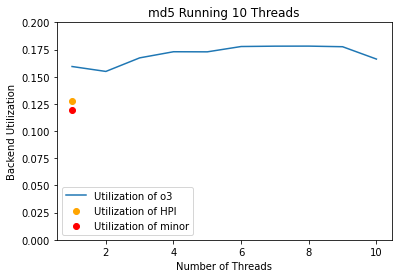

[0.15939066 0.15486552 0.16734429 0.17297301 0.17288527 0.17778041
 0.1781014  0.17814908 0.17759031 0.16624047]


In [53]:
import matplotlib.pyplot as plt

plt.plot(xpoints, utilization, label = "Utilization of o3")
plt.scatter(1, hpi_utilization, label = "Utilization of HPI", color="orange")
plt.scatter(1, minor_utilization, label = "Utilization of minor", color="red")
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads")
plt.ylabel("Backend Utilization")
plt.ylim(ymin=0, ymax=0.2)
plt.legend()
plt.show()
print(utilization)

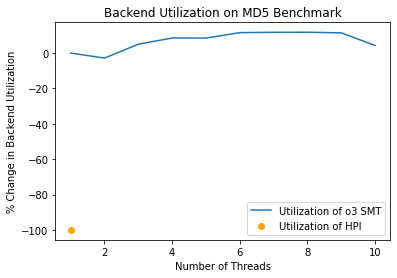

[0.15939066 0.15486552 0.16734429 0.17297301 0.17288527 0.17778041
 0.1781014  0.17814908 0.17759031 0.16624047]


In [38]:
import matplotlib.pyplot as plt

plt.plot(xpoints, (utilization/utilization[0] - 1)*100, label = "Utilization of o3 SMT")
plt.scatter(1, (hpi_utilization/utilization[0] - 1)*100, label = "Utilization of HPI", color="orange")
plt.title("Backend Utilization on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("% Change in Backend Utilization")
plt.legend()
plt.savefig('graphs/utilization_fig.png')
plt.show()
print(utilization)

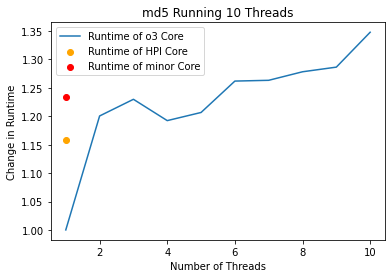

[0.001466 0.00176  0.001803 0.001748 0.001769 0.00185  0.001852 0.001874
 0.001886 0.001976]
0.001698
0.001809


In [49]:
import matplotlib.pyplot as plt

plt.plot(xpoints, numSecs/numSecs[0], label = "Runtime of o3 Core")
plt.scatter(1, hpi_numSecs/numSecs[0], label = "Runtime of HPI Core", color="orange")
plt.scatter(1, minor_numSecs/numSecs[0], label = "Runtime of minor Core", color="red")
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads")
plt.ylabel("Change in Runtime")
plt.legend()
plt.savefig("graphs/hpi_graph.png")
plt.show()
print(numSecs)
print(hpi_numSecs)
print(minor_numSecs)

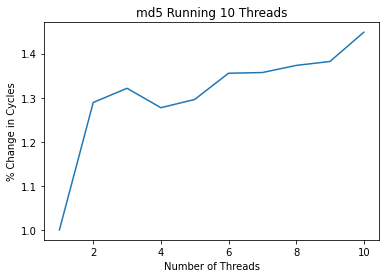

[5457813. 7036174. 7211796. 6971170. 7073335. 7398011. 7406568. 7494816.
 7543632. 7905662.]


In [40]:
plt.plot(xpoints, numCycles/numCycles[0], label = "cycles")
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads")
plt.ylabel("% Change in Cycles")
plt.legend()
plt.show()
print(numCycles)

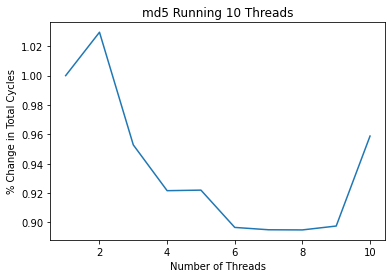

[10207780. 10509413.  9726066.  9407670.  9411466.  9152144.  9135846.
  9134794.  9161814.  9787454.]


In [41]:
plt.plot(xpoints, totalNumCycles/totalNumCycles[0], label = "total cycles")
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads")
plt.ylabel("% Change in Total Cycles")
plt.legend()
plt.show()
print(totalNumCycles)

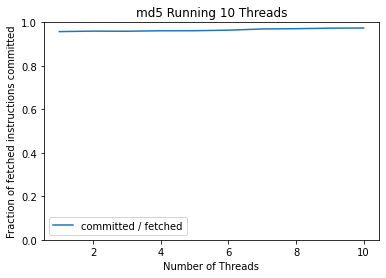

[0.95747144 0.95970771 0.95919096 0.96136679 0.96158351 0.96403842
 0.96953293 0.97092724 0.97322778 0.97405859]


In [4]:
plt.plot(xpoints, instsEfficiency, label = "committed / fetched")
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads")
plt.ylabel("Fraction of fetched instructions committed")
plt.legend()
plt.ylim(ymin=0, ymax=1)
plt.show()
print(instsEfficiency)

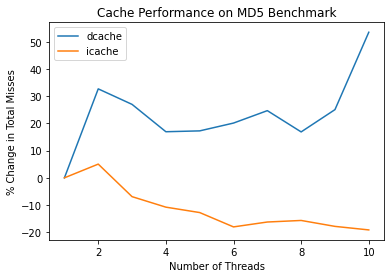

[22848. 30319. 29016. 26719. 26791. 27447. 28490. 26704. 28576. 35074.]
[2617. 2749. 2436. 2335. 2283. 2145. 2192. 2207. 2150. 2116.]


In [11]:
plt.plot(xpoints, (dcache_overallMisses/dcache_overallMisses[0]-1)*100, label = "dcache")
plt.plot(xpoints, (icache_overallMisses/icache_overallMisses[0]-1)*100, label = "icache")
plt.title("Cache Performance on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("% Change in Total Misses")
plt.legend()
plt.savefig('graphs/caches_fig.png')
plt.show()
print(dcache_overallMisses)
print(icache_overallMisses)

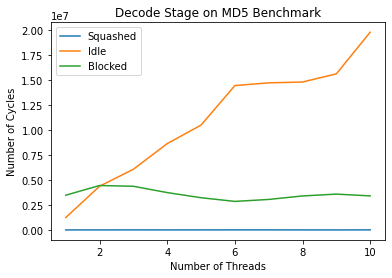

[ 1245344.  4373284.  6068087.  8627600. 10474774. 14419948. 14691277.
 14773684. 15587145. 19742906.]
[3475806. 4442028. 4364843. 3736361. 3222846. 2854685. 3051931. 3400752.
 3584232. 3404715.]
[ 9781.  9503. 11330.  9396. 10698. 13885. 13511.  9375.  9311. 10961.]


In [4]:
plt.plot(xpoints, decode_squashCycles, label = "Squashed")
plt.plot(xpoints, decode_idleCycles, label = "Idle")
plt.plot(xpoints, decode_blockedCycles, label = "Blocked")
plt.title("Decode Stage on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Cycles")
plt.legend()
plt.savefig('graphs/decode.png')
plt.show()
print(decode_idleCycles)
print(decode_blockedCycles)
print(decode_squashCycles)

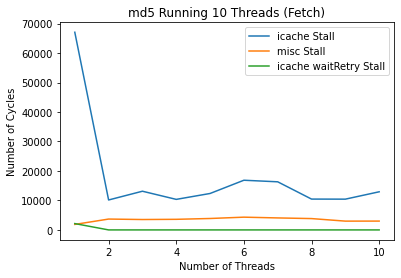

[67068. 10160. 13128. 10362. 12363. 16856. 16323. 10462. 10438. 12936.]
[1865. 3684. 3527. 3596. 3876. 4326. 4068. 3847. 2983. 2994.]
[2149.    0.    0.    0.    0.    0.    0.    0.    0.    0.]


In [45]:
plt.plot(xpoints, fetch_icacheStallCycles, label = "icache Stall")
plt.plot(xpoints, fetch_miscStallCycles, label = "misc Stall")
plt.plot(xpoints, fetch_icacheWaitRetryStallCycles, label = "icache waitRetry Stall")
plt.title("md5 Running 10 Threads (Fetch)")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Cycles")
plt.legend()
plt.show()
print(fetch_icacheStallCycles)
print(fetch_miscStallCycles)
print(fetch_icacheWaitRetryStallCycles)

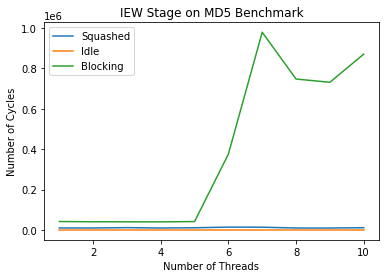

[ 9781.  9503. 11330.  9396. 10698. 13885. 13511.  9375.  9311. 10961.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 41592.  40324.  40137.  39793.  41429. 375397. 978932. 747288. 731086.
 870314.]


In [12]:
plt.plot(xpoints, iew_squashCycles, label = "Squashed")
plt.plot(xpoints, iew_idleCycles, label = "Idle")
plt.plot(xpoints, iew_blockCycles, label = "Blocking")
plt.title("IEW Stage on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Cycles")
plt.legend()
plt.savefig('graphs/iew_fig.png')
plt.show()
print(iew_squashCycles)
print(iew_idleCycles)
print(iew_blockCycles)

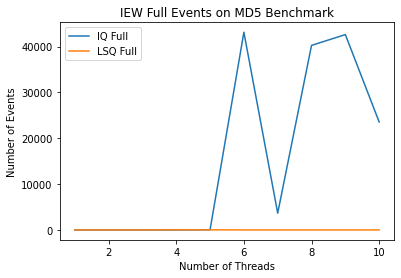

[0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 3.6000e+01 4.3123e+04
 3.6590e+03 4.0256e+04 4.2609e+04 2.3550e+04]
[ 0.  0.  0. 27. 17.  0.  0.  0.  0.  0.]


In [13]:
plt.plot(xpoints, iew_iqFullEvents, label = "IQ Full")
plt.plot(xpoints, iew_lsqFullEvents, label = "LSQ Full")
plt.title("IEW Full Events on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Events")
plt.legend()
plt.savefig('graphs/iew2_fig.png')
plt.show()
print(iew_iqFullEvents)
print(iew_lsqFullEvents)


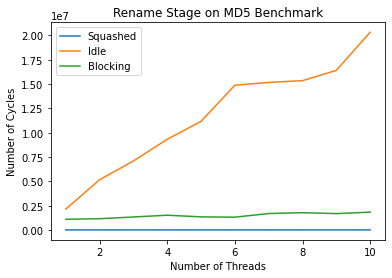

[ 9781.  9503. 11330.  9396. 10698. 13885. 13511.  9375.  9311. 10961.]
[ 2149142.  5168131.  7092936.  9320540. 11164013. 14873369. 15168130.
 15346171. 16403472. 20320758.]
[1102064. 1160387. 1337696. 1519108. 1349472. 1319871. 1693817. 1779545.
 1683928. 1835727.]


In [14]:
plt.plot(xpoints, rename_squashCycles, label = "Squashed")
plt.plot(xpoints, rename_idleCycles, label = "Idle")
plt.plot(xpoints, rename_blockCycles, label = "Blocking")
plt.title("Rename Stage on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Cycles")
plt.legend()
plt.savefig('graphs/rename_fig.png')
plt.show()
print(rename_squashCycles)
print(rename_idleCycles)
print(rename_blockCycles)

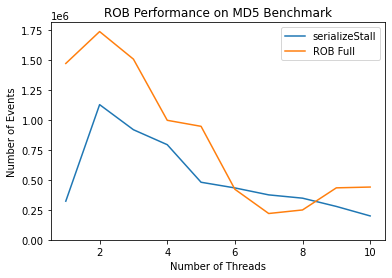

[ 321704. 1125899.  916945.  792292.  479401.  432167.  374240.  346799.
  277939.  198785.]
[1468899. 1734483. 1504818.  995419.  945203.  420866.  219044.  248618.
  432785.  439400.]


In [16]:
plt.plot(xpoints, rename_serializeStallCycles, label = "serializeStall")
plt.plot(xpoints, rename_ROBFullEvents, label = "ROB Full")
plt.title("ROB Performance on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Events")
plt.ylim(ymin=0)
plt.legend()
plt.savefig('graphs/rob_fig.png')
plt.show()
print(rename_serializeStallCycles)
print(rename_ROBFullEvents)

In [9]:
import numpy as np
import re

iterations = 10

#General:
xpoints = np.arange(iterations) + 1
rename_ROBFullEvents_2x = np.zeros(iterations)
rename_ROBFullEvents_halfx = np.zeros(iterations)

for t in range(iterations):  
    threads = t+1  
    filename = "stats/OutputStats_ROB_2x_" + str(threads)
    stats = open(filename)
    for line in stats:
        if ".rename.ROBFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_ROBFullEvents_2x[t] += float(match.group())
    
    filename = "stats/OutputStats_ROB_halfx_" + str(threads)
    stats = open(filename)
    for line in stats:
        if ".rename.ROBFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_ROBFullEvents_halfx[t] += float(match.group())

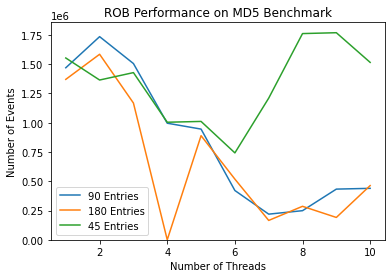

[1468899. 1734483. 1504818.  995419.  945203.  420866.  219044.  248618.
  432785.  439400.]
[1369777. 1584020. 1167736.       0.  888944.  518088.  165425.  285928.
  190822.  462905.]
[1552244. 1364166. 1427456. 1003722. 1010702.  741996. 1209465. 1760680.
 1768059. 1514679.]


In [10]:
plt.plot(xpoints, rename_ROBFullEvents, label = "90 Entries")
plt.plot(xpoints, rename_ROBFullEvents_2x, label = "180 Entries")
plt.plot(xpoints, rename_ROBFullEvents_halfx, label = "45 Entries")
plt.title("ROB Performance on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Events")
plt.ylim(ymin=0)
plt.legend()
plt.savefig('graphs/rob_fig_scaled.png')
plt.show()
print(rename_ROBFullEvents)
print(rename_ROBFullEvents_2x)
print(rename_ROBFullEvents_halfx)

In [6]:
import numpy as np
import re

iterations = 10

#General:
xpoints = np.arange(iterations) + 1
iew_iqFullEvents_2x = np.zeros(iterations)
iew_iqFullEvents_4x = np.zeros(iterations)

rename_ROBFullEvents_2x = np.zeros(iterations)
rename_ROBFullEvents_4x = np.zeros(iterations)

for t in range(iterations):  
    threads = t+1  
    filename = "stats/OutputStats_IQ_2x_" + str(threads)
    stats = open(filename)
    for line in stats:
        if ".iew.iqFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_iqFullEvents_2x[t] += float(match.group())
        if ".rename.ROBFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_ROBFullEvents_2x[t] += float(match.group())
    
    filename = "stats/OutputStats_IQ_4x_" + str(threads)
    stats = open(filename)
    for line in stats:
        if ".iew.iqFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_iqFullEvents_4x[t] += float(match.group())
        if ".rename.ROBFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_ROBFullEvents_4x[t] += float(match.group())

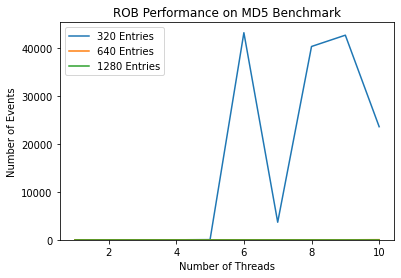

[0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 3.6000e+01 4.3123e+04
 3.6590e+03 4.0256e+04 4.2609e+04 2.3550e+04]
[ 0.  0.  0.  0.  0.  0.  0.  0.  0. 27.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [8]:
plt.plot(xpoints, iew_iqFullEvents, label = "320 Entries")
plt.plot(xpoints, iew_iqFullEvents_2x, label = "640 Entries")
plt.plot(xpoints, iew_iqFullEvents_4x, label = "1280 Entries")
plt.title("IQ Performance on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Events")
plt.ylim(ymin=0)
plt.legend()
plt.savefig('graphs/iq_fig_scaled.png')
plt.show()
print(iew_iqFullEvents)
print(iew_iqFullEvents_2x)
print(iew_iqFullEvents_4x)

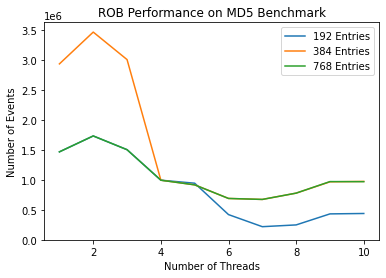

[1468899. 1734483. 1504818.  995419.  945203.  420866.  219044.  248618.
  432785.  439400.]
[2937798. 3468966. 3009636.  995420.  917711.  690620.  674202.  779419.
  968213.  974829.]
[1468899. 1734483. 1504818.  995420.  917711.  690620.  674202.  779420.
  972279.  970871.]


In [7]:
import matplotlib.pyplot as plt

plt.plot(xpoints, rename_ROBFullEvents, label = "192 Entries")
plt.plot(xpoints, rename_ROBFullEvents_2x, label = "384 Entries")
plt.plot(xpoints, rename_ROBFullEvents_4x, label = "768 Entries")
plt.title("ROB Performance on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Events")
plt.ylim(ymin=0)
plt.legend()
plt.savefig('graphs/rob_fig_scaled.png')
plt.show()
print(rename_ROBFullEvents)
print(rename_ROBFullEvents_2x)
print(rename_ROBFullEvents_4x)